## Download our **Insurance Claims** Data

"*In the insurance industry, accurately predicting the likelihood of claims is essential for risk assessment and policy pricing. However, insurance claims datasets frequently suffer from class imbalance, where the number of non-claims instances far exceeds that of actual claims. This class imbalance poses challenges for predictive modeling, often leading to biased models favoring the majority class, resulting in subpar performance for the minority class, which is typically of greater interest.* "

Data by: *Sergey Litvinenko*




In [ ]:
# !pip install xgboost lightgbm optuna scikit-learn pandas numpy matplotlib seaborn
# !pip install -r requirements.txt
# Python 3.12.13

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_recall_curve, average_precision_score,
    roc_curve, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline


We use kagglehub to download the dataset via Kaggle API, so we skip the directory configuration

| Feature | Description |
|---|---|
| `policy_id` | Unique identifier for the insurance policy |
| `subscription_length` | The duration for which the insurance policy is active |
| `customer_age` | Age of the insurance policyholder, which can influence the likelihood of claims |
| `vehicle_age` | Age of the vehicle insured, which may affect the probability of claims due to factors like wear and tear |
| `model` | The model of the vehicle, which could impact the claim frequency due to model-specific characteristics |
| `fuel_type` | Type of fuel the vehicle uses (e.g., Petrol, Diesel, CNG), which might influence the risk profile and claim likelihood |
| `max_torque`, `max_power` | Engine performance characteristics that could relate to the vehicle's mechanical condition and claim risks |
| `engine_type` | The type of engine, which might have implications for maintenance and claim rates |
| `displacement`, `cylinder` | Specifications related to the engine size and construction, affecting the vehicle's performance and potentially its claim history |
| `region_code` | The code representing the geographical region of the policyholder, as claim patterns can vary regionally |
| `region_density` | Population density of the policyholder's region, which could correlate with accident and claim frequencies |
| `airbags` | The number of airbags in the vehicle, indicating safety level which can influence claim probability |
| `is_esc`, `is_adjustable_steering`, `is_tpms` | Features that enhance vehicle safety (Electronic Stability Control, Steering, Tire Pressure Monitoring) and could potentially reduce the likelihood of claims |
| `is_parking_sensors`, `is_parking_camera` | Parking aids that might affect the probability of making a claim, especially in urban areas |
| `rear_brakes_type` | Type of rear brakes, which could be related to the vehicle's stopping capability and safety |
| Vehicle Amenities | Various binary indicators (Yes/No) for specific vehicle amenities and safety features |
| Physical Dimensions | Features like `steering_type`, `turning_radius`, `length`, `width`, `gross_weight`, etc., which build a profile of the vehicle's risk factors |
| `claim_status` | **Target Variable:** Indicates whether a claim was made (1) or not (0) |

*Source: https://www.kaggle.com/datasets/litvinenko630/insurance-claims*

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("litvinenko630/insurance-claims")

#print("Path to dataset files:", path)

# List all files in the downloaded directory
files = os.listdir(path)
#print("Files in directory:", files)

Path to dataset files: /Users/tienle/.cache/kagglehub/datasets/litvinenko630/insurance-claims/versions/1


In [3]:
# join directory path with our target dataset 
# Windows uses \ , and Mac/Linux uses / , so this helps with reproducibility
file_path = os.path.join(path, "Insurance claims data.csv")
df = pd.read_csv(file_path)
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


We need to normalize to just integers `` max_torque_nm
max_torque_rpm
max_power_bhp
max_power_rpm ``. Currently formatted as 250Nm@2750rpm

In [4]:
# Parse max_torque: "250Nm@2750rpm" -> extract 250
df['max_torque_nm'] = df['max_torque'].str.extract(r'(\d+\.?\d*)Nm').astype(float)
df['max_torque_rpm'] = df['max_torque'].str.extract(r'@(\d+)rpm').astype(float)
    
# Parse max_power: "87.8bhp@6000rpm" -> extract 87.8
df['max_power_bhp'] = df['max_power'].str.extract(r'(\d+\.?\d*)bhp').astype(float)
df['max_power_rpm'] = df['max_power'].str.extract(r'@(\d+)rpm').astype(float)

df.drop(['max_torque', 'max_power'], axis=1, inplace=True)
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,engine_type,...,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status,max_torque_nm,max_torque_rpm,max_power_bhp,max_power_rpm
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,1.5 L U2 CRDi,...,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,i-DTEC,...,Yes,Yes,Yes,Yes,4,0,200.0,1750.0,97.89,3600.0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,1.5 L U2 CRDi,...,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,F8D Petrol Engine,...,No,No,No,Yes,0,0,60.0,3500.0,40.36,6000.0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,1.5 Turbocharged Revotorq,...,No,No,Yes,Yes,5,0,200.0,3000.0,88.77,4000.0


For binary columns, using Yes/No, it is formated as literal strings. In order for our model to interpret them, we need to convert to binary numbers (0/1)

In [5]:
# Identify binary Yes/No columns
binary_cols = [col for col in df.columns if df[col].dtype == 'object' 
                and set(df[col].unique()).issubset({'Yes', 'No'})]
    
# Convert Yes/No to 1/0
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

For categorical columns, we perform One Hot Encoding that would assign each category to their own column in binary. 

In [6]:
# Identify remaining categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [7]:
print(f"Processed shape: {df.shape}")
print(f"\nFeature types after processing:")
print(df.dtypes.value_counts())

Processed shape: (58592, 58677)

Feature types after processing:
bool       58660
int64         10
float64        7
Name: count, dtype: int64


In [8]:
print("Check Missing Values")
print(df.isna().sum().value_counts())
print("\nCheck Duplicate Values")
print(df.duplicated().value_counts())

Check Missing Values
0    58677
Name: count, dtype: int64

Check Duplicate Values
False    58592
Name: count, dtype: int64


Our dataset is luckily does not have any Null or NaN values, or duplicate values.

In [9]:
# Separate features and target
X = df.drop('claim_status', axis=1)
y = df['claim_status']

# Train-test split (STRATIFIED to preserve class ratio)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {x_train.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 46873 samples
Test set: 11719 samples

Training class distribution:
claim_status
0    43875
1     2998
Name: count, dtype: int64


# Investigate why a model would fail

Starting with a Logistic Regression

We prep our features usings a StandardScaler that would standardize features by removing the mean and scale to unit variance. (Mean = 0, sigma = 1).

$ z = \frac{x - \mu}{\sigma}$

We use a Logistic Regression model to help us classify a claim and no claim holders. It uses a sigmoid curve to predict verdict (Y) between 0 and 1. 

In [10]:
# Scale features 
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(x_train)
X_test_scaled   = scaler.transform(x_test)

# Baseline model
baseline_model  = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("BASELINE MODEL (No Imbalance Handling)")
print("=" * 60)
print(f"\nAccuracy: {(y_pred_baseline == y_test).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['No Claim', 'Claim']))

BASELINE MODEL (No Imbalance Handling)

Accuracy: 0.9360

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      1.00      0.97     10969
       Claim       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



This results shows that out of the 750 no claims, the model recalled 0% of it. Meaning that this is a pretty bad approach to put in the current dataset into a model. 

Hence, there seems to be some kind of dominance, outlier or imbalance between the no claim and claim data. 

## Imbalance Ratio 

From the insurance company perspective, we want customers paying premiums to claim as little as possible, so that it is not costing the company money in payouts. Hence, we should see an **imbalance in the claim status percentage.**

In [11]:
print(df['claim_status'].value_counts(normalize=True))

claim_status
0    0.936032
1    0.063968
Name: proportion, dtype: float64


Exploring Data: 
- 93.6% of policy holder does not file a claim. 
- 6.4% of policy holder files for a claim. 

Hence, we want to identify the policy holders who would file for a claim -- considered as "high-risk" customer. We want our model to be identifying policy holders who would most likely to make a claim, and hence, measure the risk and adjust policy pricing for them. 

## Policy Holder Info

### Define Age Groups using standard Insurance age converage

Let's classify Auto Insurance Age into categories for now
- Teen / Learners Permit : 16-19 w/ DP
- Young Driver: Under 25 w/ DL
- Young Adults: Under 35
- Millenials: Under 55
- Seniors: under 75
- Elderly: 75+

In [12]:
print(f'Min Age: {df['customer_age'].min()}\nMax Age: {df['customer_age'].max()}')

Min Age: 35
Max Age: 75


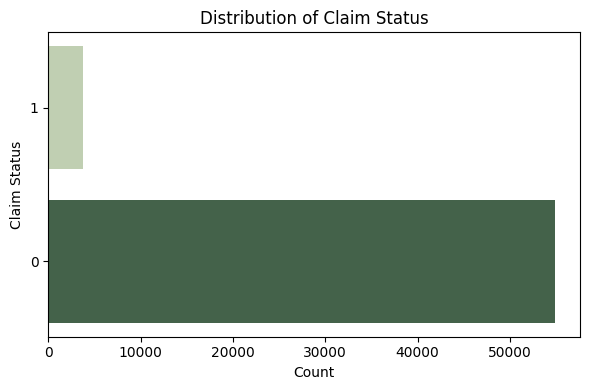

In [13]:
plt.figure(figsize=(6, 4))
counts = df['claim_status'].value_counts().sort_index()
plt.barh(counts.index.astype(str), counts.values, color=['#44624a', '#c0cfb2'])
plt.xlabel('Count')
plt.ylabel('Claim Status')
plt.title('Distribution of Claim Status')

plt.tight_layout()
plt.show()

In [16]:
df.columns

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density',
       'airbags', 'displacement', 'cylinder', 'turning_radius', 'length',
       'width',
       ...
       'is_rear_window_washer_Yes', 'is_rear_window_defogger_Yes',
       'is_brake_assist_Yes', 'is_power_door_locks_Yes',
       'is_central_locking_Yes', 'is_power_steering_Yes',
       'is_driver_seat_height_adjustable_Yes',
       'is_day_night_rear_view_mirror_Yes', 'is_ecw_Yes',
       'is_speed_alert_Yes'],
      dtype='str', length=58677)

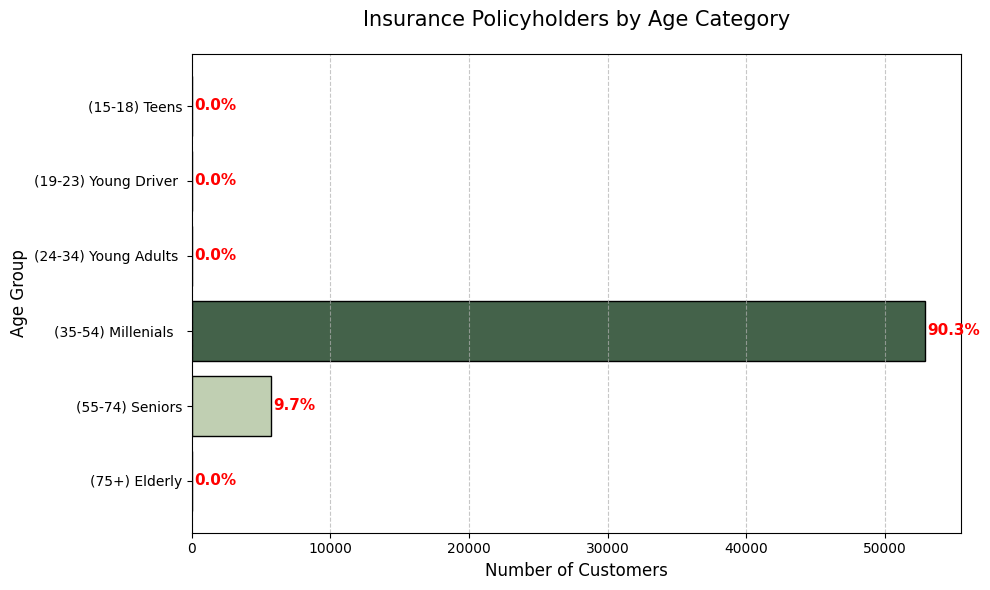

In [ ]:
bins = [15, 19, 24, 34, 54, 74, 100]
labels = [
    '(15-18) Teens', 
    '(19-23) Young Driver ', 
    '(24-34) Young Adults ', 
    '(35-54) Millenials  ', 
    '(55-74) Seniors', 
    '(75+) Elderly'
] 

df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
age_counts = df['age_group'].value_counts().sort_index()
n = df.shape[0]

percentages = age_counts / n * 100
percentage_labels = [f'{p:.1f}%' for p in percentages]

bars = plt.barh(age_counts.index.astype(str), age_counts.values, color=['#c0cfb2', '#44624a'], edgecolor='black')

plt.title('Insurance Policyholders by Age Category', fontsize=15, pad=20)
plt.xlabel('Number of Customers', fontsize=12) # Swapped to X
plt.ylabel('Age Group', fontsize=12)           # Swapped to Y
plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Percentage to the right of each bar
plt.bar_label(bars, labels=percentage_labels, padding=2, fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.show()


Majority of our dataset is between 35 to 55. 

## Distribution check
Take a look at our data's distribution through numerical columns

In [ ]:
numerical_columns = df[['subscription_length', 'vehicle_age', 'customer_age', 'ncap_rating', 'region_density']].columns
numerical_columns

Index(['subscription_length', 'vehicle_age', 'customer_age', 'ncap_rating',
       'region_density'],
      dtype='str')

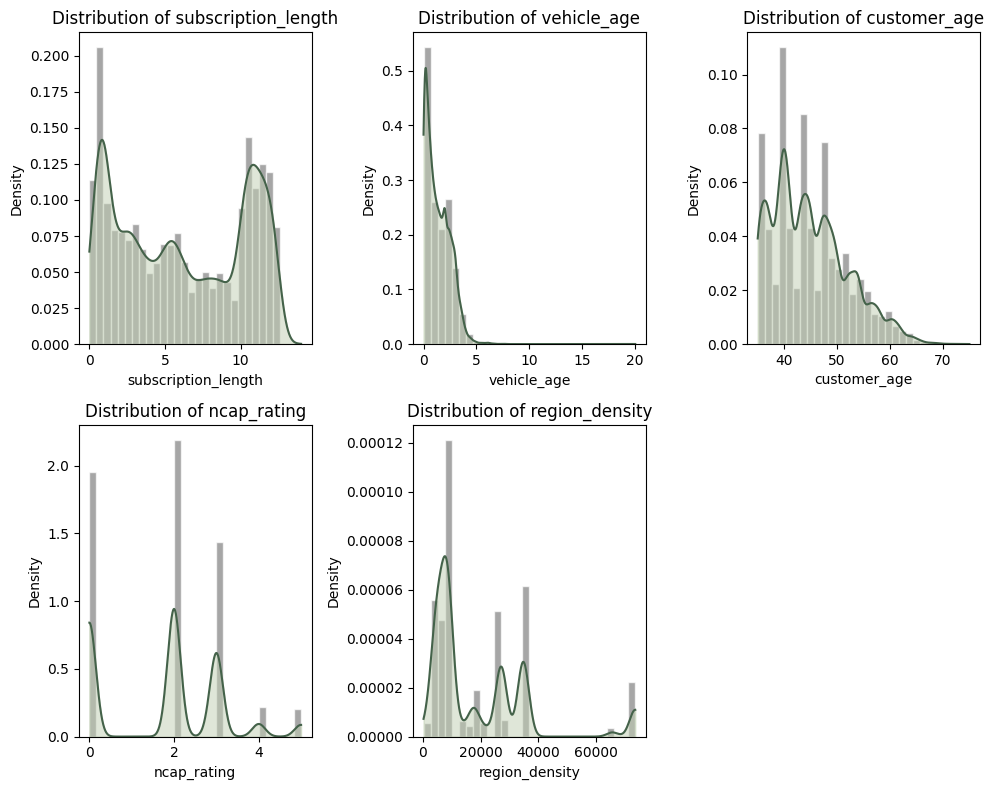

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(10, 4 * n_rows))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Get Kernel Density estimate -- helps us approximate probability density from our sample    
    data = df[col].dropna()
    plt.hist(data, bins=30, density=True, color='gray', edgecolor='white', alpha=0.7)

    kde = gaussian_kde(data)
    
    # Create X values (a smooth line from min to max) and get their Y (density) values
    x_vals = np.linspace(data.min(), data.max(), 1000)
    y_vals = kde(x_vals)
    
    plt.plot(x_vals, y_vals, color='#44624a')
    plt.fill_between(x_vals, y_vals, color='#c0cfb2', alpha=0.5) # alpha makes it slightly transparent
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    
plt.tight_layout()
plt.show()

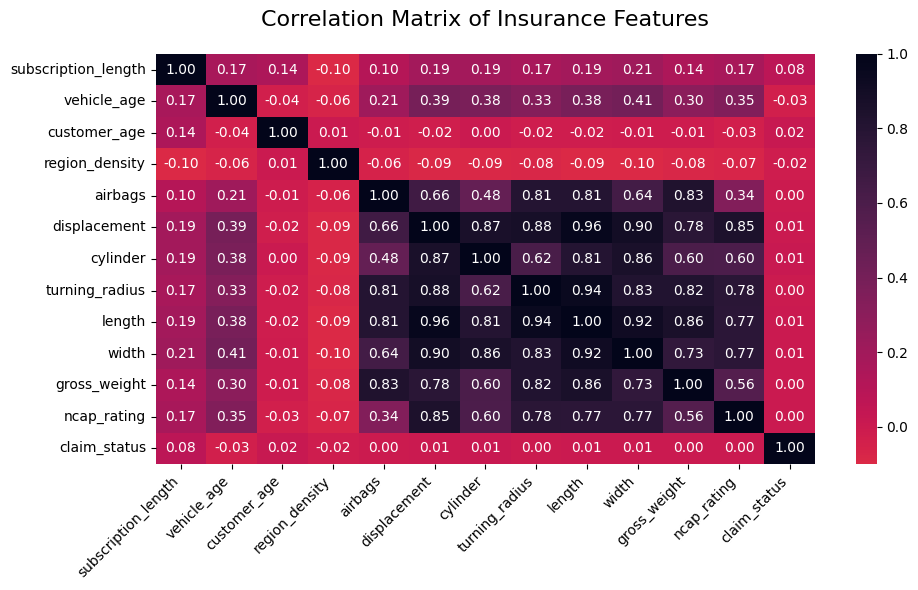

In [ ]:
# correlation Matrix
plt.figure(figsize=(10, 6))
numerical_df = df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr() # compute pairwise correlation 

sns.heatmap(corr_matrix, 
            annot = True,
            fmt = '.2f',
            cmap = 'rocket_r',
            center = 0,
            cbar_kws = {"shrink": 1},)
plt.title('Correlation Matrix of Insurance Features', fontsize=16, pad=20)

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

## Categorical Data

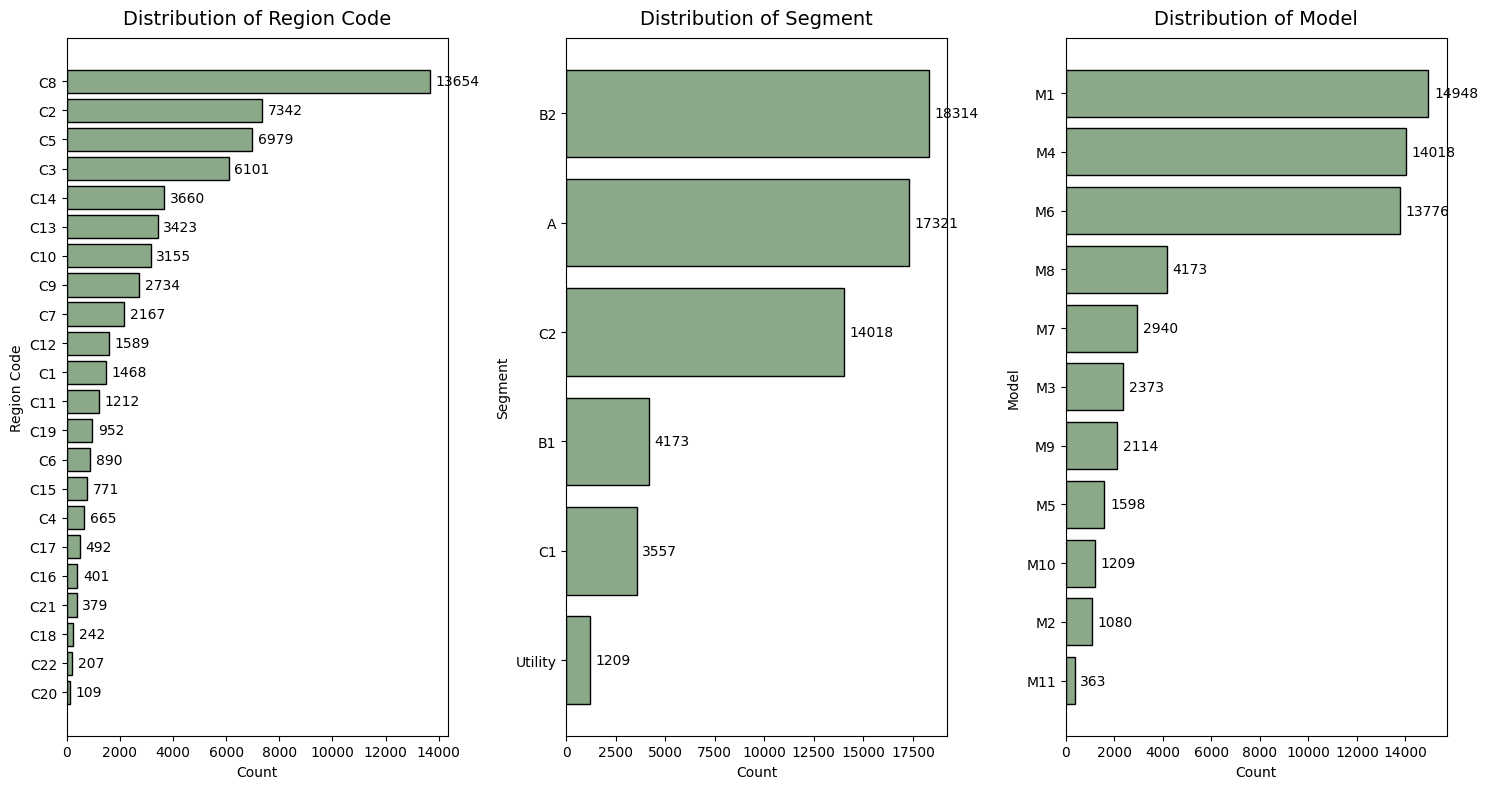

In [ ]:
categorical_columns = ['region_code', 'segment', 'model']
plt.figure(figsize=(15, 8))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, len(categorical_columns), i)
    
    counts = df[col].value_counts()

    bars = plt.barh(counts.index.astype(str), counts.values, color='#8ba888', edgecolor='black')
    
    clean_name = " ".join([el.title() for el in col.split("_")])
    plt.title(f'Distribution of {clean_name}', fontsize=14, pad=10)
    plt.xlabel('Count')
    plt.ylabel(clean_name)
    
    plt.gca().invert_yaxis()
    
    plt.bar_label(bars, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

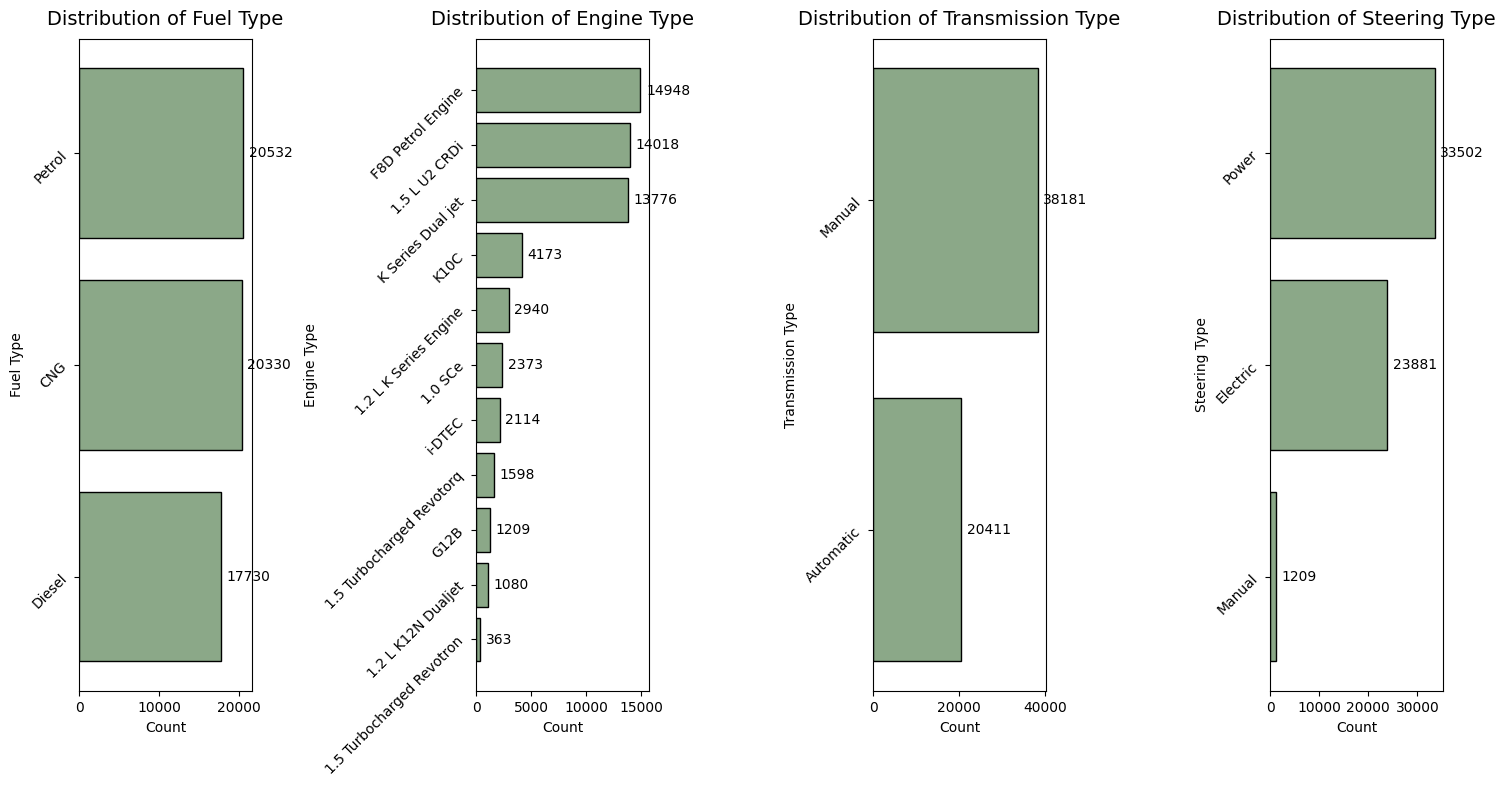

In [ ]:
internal_car_types = ['fuel_type', 'engine_type', 'transmission_type', 'steering_type']
plt.figure(figsize=(15, 8))


for i, col in enumerate(internal_car_types, 1):
    plt.subplot(1, len(internal_car_types), i)
    
    counts = df[col].value_counts()

    bars = plt.barh(counts.index.astype(str), counts.values, color='#8ba888', edgecolor='black')
    
    clean_name = " ".join([el.title() for el in col.split("_")])
    plt.title(f'Distribution of {clean_name}', fontsize=14, pad=10)
    plt.xlabel('Count')
    plt.ylabel(clean_name)
    plt.yticks(rotation=45, ha='right') 

    plt.gca().invert_yaxis()
    
    plt.bar_label(bars, padding=4, fontsize=10)

plt.tight_layout()
plt.show()


# Takeaway from our data

- The dataset is imbalanced from the claim to no claim ratios, making it quite difficult to train our models to identify individuals who would create a claim. Hence, we need to modify or rebalance our data so that both classes (claim and no claim) are representative in model training. We will *resampling techniques* such as **oversampling, undersampling.**
  - Oversampling (e.g. SMOTE): increase the number of minority samples.
  - Undersampling: decrease the number of majority samples.

- From the correlation matrix, subscription length seems to have the highest pairwise correlation coefficient, which means most claims are from long-term policy holders. 


